# **PSMDSSC 103**


Assignment 4: Random Forest

Levi P. Caaya III


MEngCpE 1st Year 2nd Sem

# **Problem Framing**
This notebook will use the Random Forest algorithm to determine the likelihood of a Diabetes patient to return to the hospital after being admitted.

Prediiction in medical field is a hot topic as many oppose the lack of expertise and self diagnosis, that's why conducting research in this field is a sensitive thing.

# **Data Preparation**

## Loading the data
The dataset used was the one attached in the activity itself
Exploratory Data Analysis was also done in this part

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'https://raw.githubusercontent.com/levi3612/ML_datasets/refs/heads/main/diabetic_data.csv'
df = pd.read_csv(file_path)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:

df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

Looking for null data, null data will be handled as it can affect the model

In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


Since null data in max_glu_serum and A1Cresult are huge (>50%), the feature will be dropped

In [ ]:
df = df.drop(columns=['max_glu_serum', 'A1Cresult'])

Looking in df.head earlier, we can see that the weight feature has question marks as value, we look further and see if those are just isolated case so we can determine what to do.

In [ ]:
df['weight'].value_counts()

,count
weight,
?,98569
[75-100),1336
[50-75),897
[100-125),625
[125-150),145
[25-50),97
[0-25),48
[150-175),35
[175-200),11


I converted the question mark to NaN

In [ ]:
df['weight'] = df['weight'].replace('?', np.nan)

In [ ]:
df['weight'].value_counts(dropna=False)

,count
weight,
NaN,98569
[75-100),1336
[50-75),897
[100-125),625
[125-150),145
[25-50),97
[0-25),48
[150-175),35
[175-200),11


In [ ]:
columns_with_question_mark = []
for col in df.columns:
    if (df[col] == '?').any():
        columns_with_question_mark.append(col)

print("Columns with '?' values:")
for col_name in columns_with_question_mark:
    print(col_name)

Columns with '?' values:
race
payer_code
medical_specialty
diag_1
diag_2
diag_3


I also checked if there are cells that has question mark as value and replace them wth NaN

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace('?', np.nan)

In [ ]:
print("Value counts after replacing '?' with NaN:")
for col_name in columns_with_question_mark:
    print(f"\nColumn: {col_name}")
    print(df[col_name].value_counts(dropna=False))

Value counts after replacing '?' with NaN:

Column: race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Column: payer_code
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64

Column: medical_specialty
medical_specialty
NaN                       49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Proctology                    1
Speech                        1
SportsMedicine                1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64

Column: diag_1
diag_1
428    6862
4

## Handling NaN

In [ ]:
#Check now for nan
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
# Drop identifier columns as they are not useful for prediction together with columns with large value of NaNs
df = df.drop(columns=['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty'])

print("Columns after dropping specified columns:")
print(df.columns)

Columns after dropping specified columns:
Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')


In [ ]:
#Check for NaN values again
df.isnull().sum()

,0
race,2273
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


Deleting Rows with NaN Values

In [ ]:
# Drop rows with any NaN values
df_cleaned = df.dropna()

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after dropping NaN rows: {df_cleaned.shape}")

df = df_cleaned.copy()

Original DataFrame shape: (101766, 43)
DataFrame shape after dropping NaN rows: (98053, 43)


In [ ]:
# Verify no more NaNs remain
print("Number of NaN values per column after dropping rows:")
print(df.isnull().sum())

Number of NaN values per column after dropping rows:
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide       

In [ ]:
df.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000
mean,2.025813,3.753368,5.776692,4.421976,43.148073,1.350749,16.119650,0.376378,0.202462,0.646864,7.512060
std,1.450117,5.309392,4.071640,2.993074,19.712033,1.708506,8.108476,1.283359,0.942892,1.271020,1.832497
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Feature Engineering

### Feature Engineering: Total Prior Visits
Create a new feature `total_prior_visits` by summing the `number_outpatient`, `number_emergency`, and `number_inpatient` columns. This will represent a patient's historical engagement with healthcare services.


In [ ]:
df['total_prior_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,NO,3
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,NO,0
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,Steady,No,No,No,No,No,No,Yes,>30,0


### Feature Engineering: Medication Use

I need to create the `num_drugs_active` feature. First, I will identify all columns related to medications to count how many drugs a patient is actively taking. Based on the `df.info()` output, columns from 'metformin' to 'metformin-pioglitazone' seem to be medication-related. I will check the unique values in 'metformin' to confirm how to identify active medication status.



In [ ]:
print(df['metformin'].value_counts())

metformin
No        78808
Steady    17677
Up         1017
Down        551
Name: count, dtype: int64



Based on the `value_counts()` for 'metformin', 'Steady', 'Up', and 'Down' indicate an active medication status, while 'No' indicates inactive. I need to identify all medication columns, then count for each row how many of these medications have an 'active' status ('Steady', 'Up', 'Down') to create the `num_drugs_active` feature. Finally, I'll display the head of the DataFrame to show the new column.



In [ ]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

# Count the number of active drugs for each patient
df['num_drugs_active'] = df[medication_cols].apply(
    lambda x: (x != 'No').sum(), axis=1
)

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits,num_drugs_active
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,No,No,No,Ch,Yes,>30,0,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,Yes,NO,3,1
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,No,No,No,Ch,Yes,NO,0,1
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,No,No,No,Ch,Yes,NO,0,2
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,No,No,No,No,No,Yes,>30,0,1


### Feature Engineering: Time in Hospital
To create the `time_in_hospital_binned` feature, I will discretize the `time_in_hospital` column into meaningful categories using `pd.cut` and then display the head of the DataFrame to show the new column.



In [ ]:
bins = [0, 3, 7, 14]
labels = ['1-3 days', '4-7 days', '8-14 days']
df['time_in_hospital_binned'] = pd.cut(df['time_in_hospital'], bins=bins, labels=labels, right=True, include_lowest=True)
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits,num_drugs_active,time_in_hospital_binned
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,No,No,Ch,Yes,>30,0,1,1-3 days
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,Yes,NO,3,1,1-3 days
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,No,No,Ch,Yes,NO,0,1,1-3 days
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,No,No,Ch,Yes,NO,0,2,1-3 days
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,No,No,No,No,Yes,>30,0,1,1-3 days


Now check the whole dataset

In [ ]:
df.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,total_prior_visits,num_drugs_active
count,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000
mean,2.025813,3.753368,5.776692,4.421976,43.148073,1.350749,16.119650,0.376378,0.202462,0.646864,7.512060,1.225704,1.178251
std,1.450117,5.309392,4.071640,2.993074,19.712033,1.708506,8.108476,1.283359,0.942892,1.271020,1.832497,2.314734,0.921824
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000,1.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,2.000000,2.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,80.000000,6.000000


In [ ]:
df.shape

(98053, 46)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98053 entries, 1 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   race                      98053 non-null  object  
 1   gender                    98053 non-null  object  
 2   age                       98053 non-null  object  
 3   admission_type_id         98053 non-null  int64   
 4   discharge_disposition_id  98053 non-null  int64   
 5   admission_source_id       98053 non-null  int64   
 6   time_in_hospital          98053 non-null  int64   
 7   num_lab_procedures        98053 non-null  int64   
 8   num_procedures            98053 non-null  int64   
 9   num_medications           98053 non-null  int64   
 10  number_outpatient         98053 non-null  int64   
 11  number_emergency          98053 non-null  int64   
 12  number_inpatient          98053 non-null  int64   
 13  diag_1                    98053 non-null  object  

In [ ]:
df['readmitted'].head()

,readmitted
1,>30
2,NO
3,NO
4,NO
5,>30


Since readmission data says 'no', '>30' (readmitted after 30 days), and '<30' (readmitted under 30 days), I will transform it to binary 1/0 for Yes/No Readmission

In [ ]:
# Map 'NO' to 0 and '<30', '>30' to 1 for binary classification
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

# Drop the original 'readmitted' column
df = df.drop(columns=['readmitted'])

# Display the head of the DataFrame with the new target column
display(df[['readmitted_binary']].head())

,readmitted_binary
1,1
2,0
3,0
4,0
5,1


## Declaring Variables and One Hot Encoding

In [ ]:
# Separate target variable 'y' from features 'X'
X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (98053, 45)
Shape of y: (98053,)


In [ ]:
# Identify categorical columns for one-hot encoding, including both 'object' and 'category' dtypes
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to categorical columns in X
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape of X after one-hot encoding: {X_encoded.shape}")
display(X_encoded.head())

Shape of X after one-hot encoding: (98053, 2315)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,time_in_hospital_binned_4-7 days,time_in_hospital_binned_8-14 days
1,1,1,7,3,59,0,18,0,0,0,...,True,False,False,False,False,False,False,True,False,False
2,1,1,7,2,11,5,13,2,0,1,...,True,False,False,False,False,False,True,True,False,False
3,1,1,7,2,44,1,16,0,0,0,...,True,False,False,False,False,False,False,True,False,False
4,1,1,7,1,51,0,8,0,0,0,...,True,False,False,False,False,False,False,True,False,False
5,2,1,2,3,31,6,16,0,0,0,...,True,False,False,False,False,False,True,True,False,False


## Splitting Training and Testing Portions

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Baseline Model

We will use decision tree as the baseline model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

In [ ]:
# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Decision Tree Classifier Performance:
Accuracy: 0.5734
Precision: 0.5447
Recall: 0.5392
F1-Score: 0.5419
ROC-AUC Score: 0.5713

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60     10432
           1       0.54      0.54      0.54      9179

    accuracy                           0.57     19611
   macro avg       0.57      0.57      0.57     19611
weighted avg       0.57      0.57      0.57     19611


Confusion Matrix:
[[6296 4136]
 [4230 4949]]


# Random Forest Implementation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Initial Model
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier = rf_classifier.fit(X_train, y_train)


In [ ]:
rf_y_pred = rf_classifier.predict(X_test)



In [ ]:

# Evaluate the model
print("Initial Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_y_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_y_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))

Initial Random Forest Performance:
Accuracy: 0.6301
Precision: 0.6271
Recall: 0.5170
F1-Score: 0.5668
ROC-AUC Score: 0.6233

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68     10432
           1       0.63      0.52      0.57      9179

    accuracy                           0.63     19611
   macro avg       0.63      0.62      0.62     19611
weighted avg       0.63      0.63      0.63     19611


Confusion Matrix:
[[7610 2822]
 [4433 4746]]


Now let's do a Random search to tune hyperparameters and come up with the best model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from scipy.stats import randint

param_distributions = {
    'n_estimators': randint(50, 200),  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum number of levels in tree
    'min_samples_split': randint(2, 20),  # Minimum number of samples required to split an internal node
    'max_features': ['sqrt', 'log2'] # Number of features to consider when looking for the best split
}

print("Parameter distributions defined.")

Parameter distributions defined.


In [ ]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1  # Changed to 1 to avoid 'No space left on device' error
)

rf_random_search.fit(X_train, y_train)

print("Randomized Search complete.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=20, max_features=log2, min_samples_split=16, n_estimators=156; total time=  17.1s
[CV] END max_depth=20, max_features=log2, min_samples_split=16, n_estimators=156; total time=  10.6s
[CV] END max_depth=20, max_features=log2, min_samples_split=16, n_estimators=156; total time=  10.8s
[CV] END max_depth=30, max_features=sqrt, min_samples_split=8, n_estimators=171; total time= 1.4min
[CV] END max_depth=30, max_features=sqrt, min_samples_split=8, n_estimators=171; total time= 1.3min
[CV] END max_depth=30, max_features=sqrt, min_samples_split=8, n_estimators=171; total time= 1.3min
[CV] END max_depth=20, max_features=sqrt, min_samples_split=12, n_estimators=137; total time=  40.4s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=12, n_estimators=137; total time=  39.7s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=12, n_estimators=137; total time=  39.0s
[CV] END max_depth=None, max_feat

# Model Evaluation

In [ ]:
best_rf_model = rf_random_search.best_estimator_
print(f"Best hyperparameters found: {rf_random_search.best_params_}")

# Make predictions with the best model
rf_y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned model
print("\nTuned Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, rf_y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, rf_y_pred_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_y_pred_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_y_pred_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred_tuned))

Best hyperparameters found: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 9, 'n_estimators': 180}

Tuned Random Forest Performance:
Accuracy: 0.6332
Precision: 0.6308
Recall: 0.5216
F1-Score: 0.5711
ROC-AUC Score: 0.6265

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68     10432
           1       0.63      0.52      0.57      9179

    accuracy                           0.63     19611
   macro avg       0.63      0.63      0.63     19611
weighted avg       0.63      0.63      0.63     19611


Confusion Matrix:
[[7630 2802]
 [4391 4788]]


Top 20 Feature Importances:


,Feature,Importance
11,total_prior_visits,0.043057
9,number_inpatient,0.034900
4,num_lab_procedures,0.033585
6,num_medications,0.032603
1,discharge_disposition_id,0.023892
10,number_diagnoses,0.022299
3,time_in_hospital,0.022155
5,num_procedures,0.018405
2,admission_source_id,0.015911
0,admission_type_id,0.015853


/tmp/ipython-input-189/48649842.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


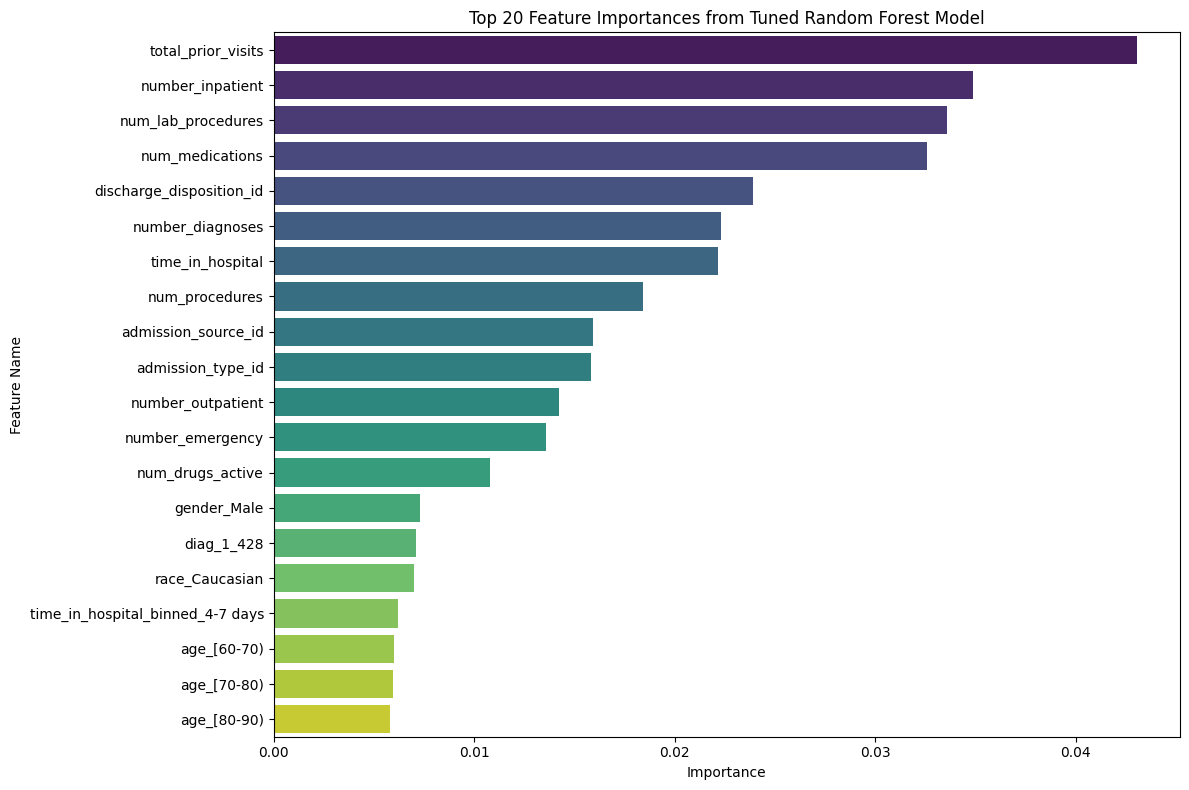

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model
feature_importances = best_rf_model.feature_importances_

# Get feature names from the encoded training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances:")
display(importance_df.head(20))

# Plot the top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Tuned Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

**Comparing ROC-AUC of Decision Tree and the tuned random forest**

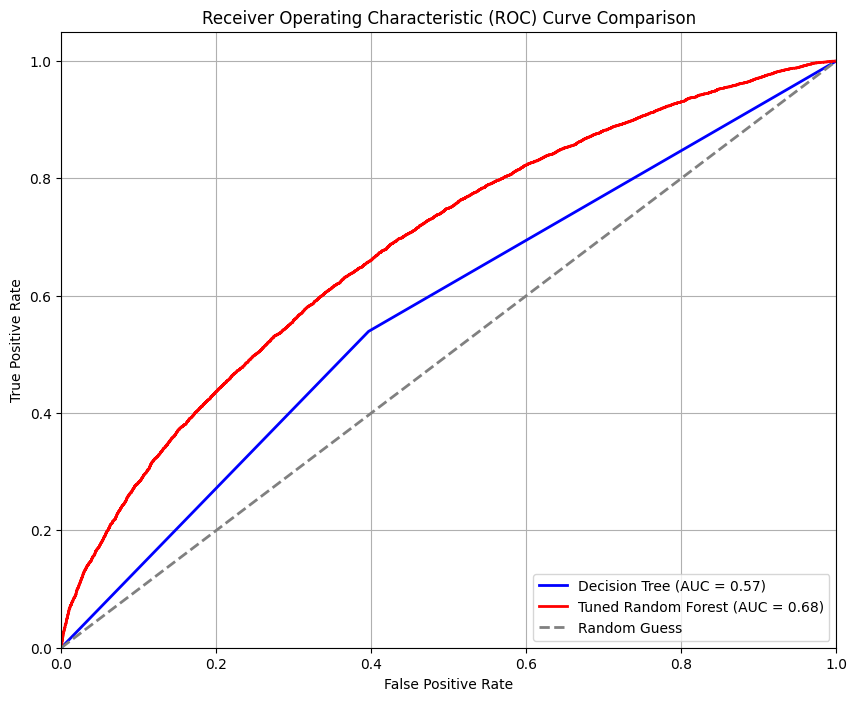

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1) for Decision Tree
y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]

# Get predicted probabilities for the positive class (class 1) for Tuned Random Forest
y_pred_proba_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve for Decision Tree
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calculate ROC curve for Tuned Random Forest
fpr_rf_tuned, tpr_rf_tuned, thresholds_rf_tuned = roc_curve(y_test, y_pred_proba_rf_tuned)
roc_auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_rf_tuned, tpr_rf_tuned, color='red', lw=2, label=f'Tuned Random Forest (AUC = {roc_auc_rf_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()